In [1]:
import tensorflow as tf
import os
import numpy as np
import cv2
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt 

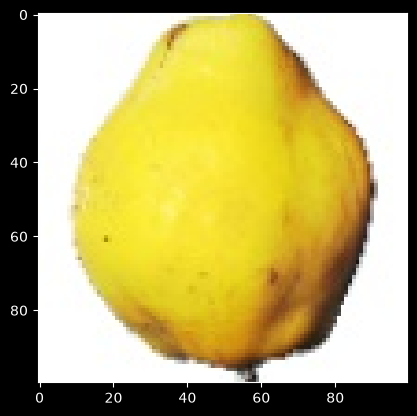

In [2]:
train_path = r'E:\iti\archive\fruits-360_100x100\fruits-360\Training'
test_path = r'E:\iti\archive\fruits-360_100x100\fruits-360\Test'

BatchSize = 64 

img = load_img(r'E:\iti\archive\fruits-360_100x100\fruits-360\Training\Quince 1\0_100.jpg')
plt.imshow (img)
plt.show()

In [3]:
imgA = img_to_array(img)
print(imgA.shape)

(100, 100, 3)


# Build the model

In [4]:
model = Sequential()
model.add(Conv2D(filters=128, kernel_size=3, activation='relu', input_shape=(100,100,3)))
model.add(MaxPool2D())
model.add(Conv2D(filters=64, kernel_size=3, activation='relu'))
model.add(Conv2D(filters=32, kernel_size=3, activation='relu'))
model.add(MaxPool2D())
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(5000, activation='relu'))
model.add(Dense(1000, activation='relu'))
model.add(Dense(260, activation='softmax'))

print(model.summary())

E:\iti\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5000)           │    77,445,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │     5,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 260)            │       260,260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,802,100 (315.86 MB)

 Trainable params: 82,802,100 (315.86 MB)

 Non-trainable params: 0 (0.00 B)

None


# Compile the Model

In [5]:
model.compile(loss='categorical_crossentropy',optimizer='SGD',metrics=['accuracy'])

# load  the data

In [9]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range=0.3,
                                   horizontal_flip=True,
                                   vertical_flip=True,
                                   zoom_range=0.3)

    
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_path,
                                                    target_size=(100,100),
                                                    batch_size=BatchSize,
                                                    color_mode='rgb',
                                                    class_mode='categorical',
                                                    shuffle=True)

test_generator = test_datagen.flow_from_directory(test_path,
                                                    target_size=(100,100),
                                                    batch_size=BatchSize,
                                                    color_mode='rgb',
                                                    class_mode='categorical',
                                                    )

stepsPerEpoch = int(np.ceil(train_generator.samples / BatchSize))
ValidationSteps = int(np.ceil(test_generator.samples / BatchSize))


Found 137221 images belonging to 260 classes.
Found 45724 images belonging to 260 classes.


# Early Stopping


In [10]:
stop_early = EarlyStopping(monitor='val_accuracy',patience=5)


# Train the model

In [ ]:
history = model.fit(train_generator,
                    steps_per_epoch=stepsPerEpoch,
                    epochs=10,
                    validation_data=test_generator,
                    validation_steps=ValidationSteps,
                    callbacks=[stop_early])
model.save('model.h5')
print('Model saved')

Epoch 1/5
2145/2145 ━━━━━━━━━━━━━━━━━━━━ 1036s 483ms/step - accuracy: 0.5864 - loss: 1.3412 - val_accuracy: 0.7957 - val_loss: 0.8660
Epoch 2/5
2145/2145 ━━━━━━━━━━━━━━━━━━━━ 1016s 474ms/step - accuracy: 0.8045 - loss: 0.6135 - val_accuracy: 0.8713 - val_loss: 0.7119
Epoch 3/5
2145/2145 ━━━━━━━━━━━━━━━━━━━━ 1052s 491ms/step - accuracy: 0.8808 - loss: 0.3669 - val_accuracy: 0.9112 - val_loss: 0.6364
Epoch 4/5
2145/2145 ━━━━━━━━━━━━━━━━━━━━ 1051s 490ms/step - accuracy: 0.9134 - loss: 0.2549 - val_accuracy: 0.9116 - val_loss: 0.6113
Epoch 5/5
2145/2145 ━━━━━━━━━━━━━━━━━━━━ 1048s 488ms/step - accuracy: 0.9338 - loss: 0.1859 - val_accuracy: 0.9418 - val_loss: 0.5340


Model saved
